### Importação dos dados



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento



In [2]:
# Criando coluna de identificação
loja['Loja'] = 'Loja 1'
loja2['Loja'] = 'Loja 2'
loja3['Loja'] = 'Loja 3'
loja4['Loja'] = 'Loja 4'

# Unindo todas em um único dataframe
df_total = pd.concat([loja, loja2, loja3, loja4], ignore_index=True)

df_total.head()



,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon,Loja
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,Loja 1
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,Loja 1
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,Loja 1
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50,Loja 1
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,Loja 1


In [5]:
# Ver valores distintos da coluna Loja
df_total['Loja'].unique()


array(['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4'], dtype=object)

In [3]:

# Criando coluna de faturamento
df_total['Faturamento'] = df_total['Preço'] * df_total['Quantidade de parcelas']

# Faturamento por loja
faturamento_loja = df_total.groupby('Loja')['Faturamento'].sum().sort_values(ascending=False)

faturamento_loja


,Faturamento
Loja,
Loja 1,4563636.11
Loja 2,4449584.18
Loja 3,4325091.42
Loja 4,4131753.14


In [6]:
# Criando coluna de faturamento
df_total['Faturamento'] = df_total['Preço'] * df_total['Quantidade de parcelas']

# Faturamento total por loja (ordenado do maior para o menor)
faturamento_loja = (
    df_total
    .groupby('Loja')['Faturamento']
    .sum()
    .sort_values(ascending=False)
)

# Calculando percentual de participação
percentual_loja = (faturamento_loja / faturamento_loja.sum()) * 100

# Criando DataFrame resumo
resumo = pd.DataFrame({
    'Faturamento': faturamento_loja,
    'Percentual (%)': percentual_loja.round(2)
})

resumo


,Faturamento,Percentual (%)
Loja,,
Loja 1,4563636.11,26.12
Loja 2,4449584.18,25.47
Loja 3,4325091.42,24.76
Loja 4,4131753.14,23.65


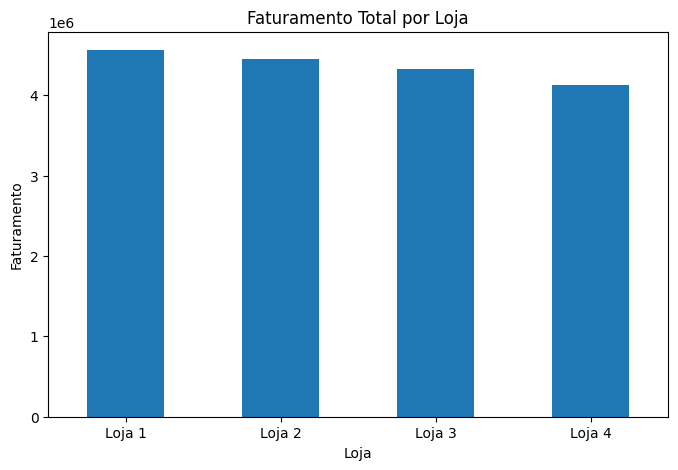

In [4]:
import matplotlib.pyplot as plt

faturamento_loja.plot(kind='bar', figsize=(8,5))
plt.title('Faturamento Total por Loja')
plt.ylabel('Faturamento')
plt.xticks(rotation=0)
plt.show()


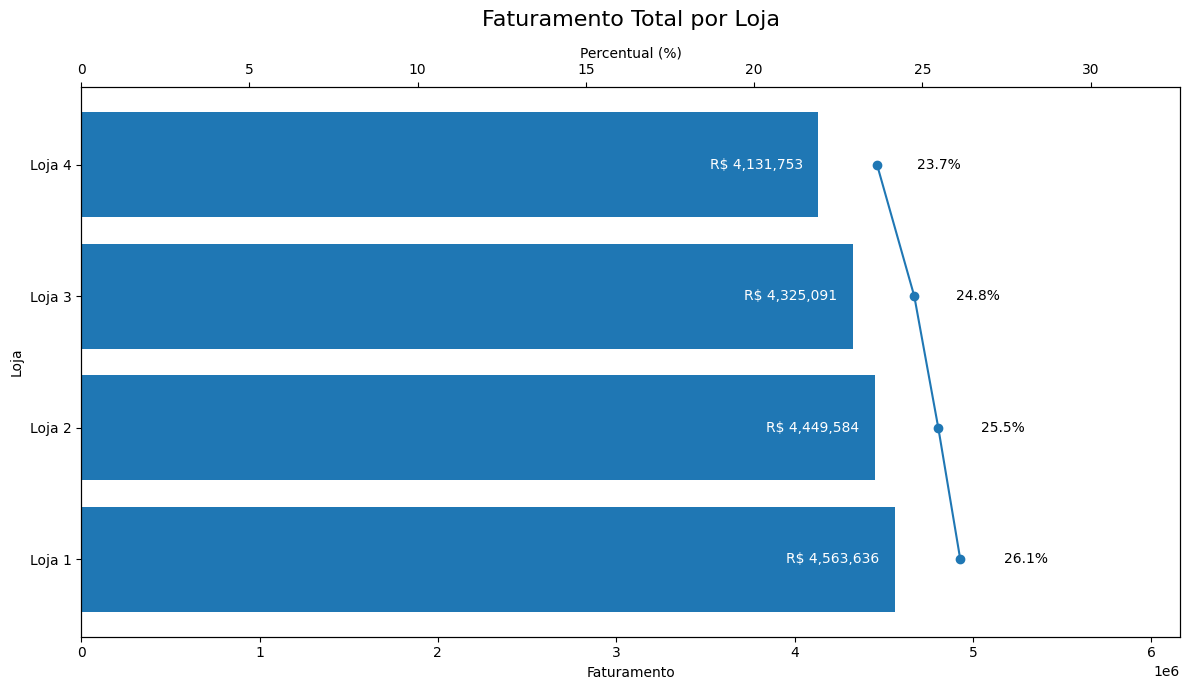

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Calculando percentual
percentual_loja = (faturamento_loja / faturamento_loja.sum()) * 100

fig, ax1 = plt.subplots(figsize=(12,7))

y = np.arange(len(faturamento_loja.index))

# Barras horizontais
barras = ax1.barh(y, faturamento_loja.values)

ax1.set_title('Faturamento Total por Loja', fontsize=16, pad=15)
ax1.set_xlabel('Faturamento')
ax1.set_ylabel('Loja')

# Aumentando espaço lateral
ax1.set_xlim(0, faturamento_loja.max() * 1.35)

# 🔹 Valor DENTRO da barra (evita conflito)
for i, valor in enumerate(faturamento_loja.values):
    ax1.text(valor * 0.98, y[i],
             f'R$ {valor:,.0f}',
             va='center',
             ha='right',
             color='white',
             fontsize=10)

# Segundo eixo para percentual
ax2 = ax1.twiny()
ax2.plot(percentual_loja.values, y, marker='o')

# Ajustando limite do eixo percentual
ax2.set_xlim(0, percentual_loja.max() * 1.25)
ax2.set_xlabel('Percentual (%)')

# 🔹 Percentual deslocado um pouco para direita
for i, perc in enumerate(percentual_loja.values):
    ax2.text(perc * 1.05, y[i],
             f'{perc:.1f}%',
             va='center',
             fontsize=10)

# Ajustando eixo Y
ax1.set_yticks(y)
ax1.set_yticklabels(faturamento_loja.index)

plt.tight_layout()
plt.show()


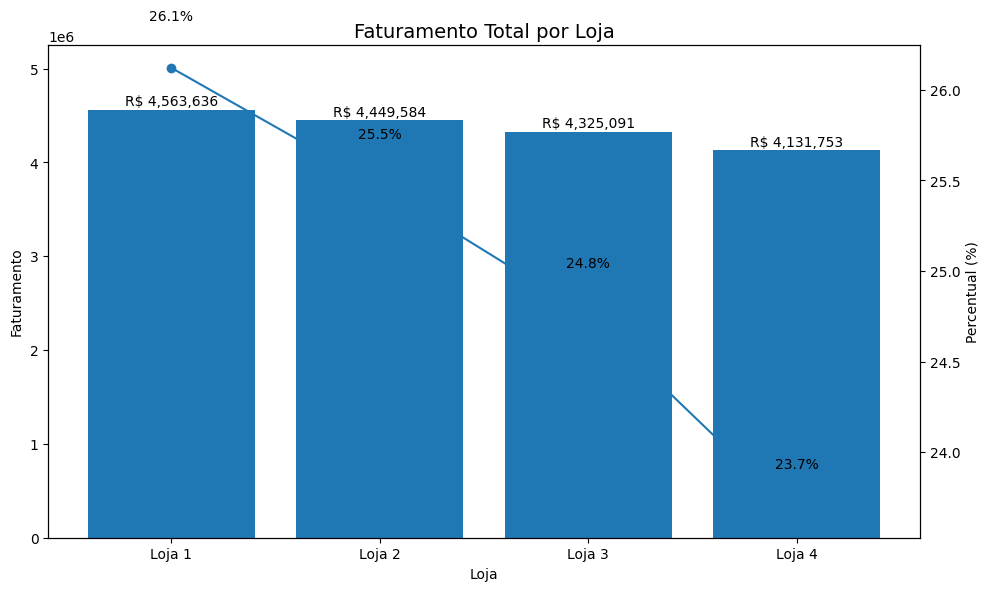

In [9]:
import matplotlib.pyplot as plt

# Calculando percentual
percentual_loja = (faturamento_loja / faturamento_loja.sum()) * 100

fig, ax1 = plt.subplots(figsize=(10,6))

# Barras
barras = ax1.bar(faturamento_loja.index, faturamento_loja.values)

ax1.set_title('Faturamento Total por Loja', fontsize=14)
ax1.set_ylabel('Faturamento')
ax1.set_xlabel('Loja')

# Aumentando limite do eixo Y (espaço para rótulos)
ax1.set_ylim(0, faturamento_loja.max() * 1.15)

# Rótulos das barras
for i, valor in enumerate(faturamento_loja.values):
    ax1.text(i, valor * 1.01,
             f'R$ {valor:,.0f}',
             ha='center')

# Segundo eixo (percentual)
ax2 = ax1.twinx()
ax2.plot(faturamento_loja.index, percentual_loja.values, marker='o')
ax2.set_ylabel('Percentual (%)')

# Pequeno deslocamento vertical para o percentual
deslocamento = percentual_loja.max() * 0.01

for i, perc in enumerate(percentual_loja.values):
    ax2.text(i, perc + deslocamento,
             f'{perc:.1f}%',
             ha='center')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 2. Vendas por Categoria

In [10]:

categorias_populares = df_total.groupby(['Loja','Categoria do Produto'])['Produto'].count().reset_index()

categorias_populares.sort_values(by=['Loja','Produto'], ascending=False)


,Loja,Categoria do Produto,Produto
30,Loja 4,moveis,480
26,Loja 4,eletronicos,451
24,Loja 4,brinquedos,338
27,Loja 4,esporte e lazer,277
25,Loja 4,eletrodomesticos,254
31,Loja 4,utilidades domesticas,201
29,Loja 4,livros,187
28,Loja 4,instrumentos musicais,170
22,Loja 3,moveis,499
18,Loja 3,eletronicos,451


In [11]:
categoria_top = (
    df_total.groupby(['Loja','Categoria do Produto'])
    .size()
    .reset_index(name='Quantidade')
    .sort_values(['Loja','Quantidade'], ascending=False)
)

categoria_top.groupby('Loja').first()


,Categoria do Produto,Quantidade
Loja,,
Loja 1,moveis,465
Loja 2,moveis,442
Loja 3,moveis,499
Loja 4,moveis,480


In [14]:
# Contando vendas por categoria dentro de cada loja
categoria_top3 = (
    df_total
        .groupby(['Loja', 'Categoria do Produto'])
        .size()
        .reset_index(name='Quantidade')
        .sort_values(['Loja', 'Quantidade'], ascending=[True, False])
)

# Criando ranking dentro de cada loja
categoria_top3['Ranking'] = (
    categoria_top3
        .groupby('Loja')['Quantidade']
        .rank(method='first', ascending=False)
)

# Pegando apenas Top 3
categoria_top3 = categoria_top3[categoria_top3['Ranking'] <= 3]

# Criando coluna combinada (Categoria + Quantidade)
categoria_top3['Categoria_Qtd'] = (
    categoria_top3['Categoria do Produto'] +
    ' (' + categoria_top3['Quantidade'].astype(str) + ')'
)

# Pivotando para formato final
top3_formatado = (
    categoria_top3
        .pivot(index='Loja', columns='Ranking', values='Categoria_Qtd')
        .rename(columns={1.0: 'Top 1', 2.0: 'Top 2', 3.0: 'Top 3'})
        .reset_index()
)

top3_formatado




Ranking,Loja,Top 1,Top 2,Top 3
0,Loja 1,moveis (465),eletronicos (448),brinquedos (324)
1,Loja 2,moveis (442),eletronicos (422),brinquedos (313)
2,Loja 3,moveis (499),eletronicos (451),brinquedos (315)
3,Loja 4,moveis (480),eletronicos (451),brinquedos (338)


# 3. Média de Avaliação das Lojas


In [17]:
avaliacao_media = (
    df_total
        .groupby('Loja')['Avaliação da compra']
        .mean()
        .sort_values(ascending=False)
        .round(2)
)

avaliacao_media


,Avaliação da compra
Loja,
Loja 3,4.05
Loja 2,4.04
Loja 4,4.00
Loja 1,3.98


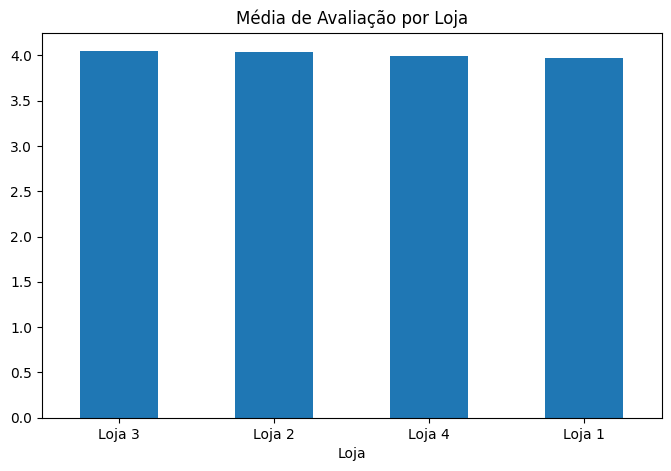

In [16]:

avaliacao_media.plot(kind='bar', figsize=(8,5))
plt.title('Média de Avaliação por Loja')
plt.xticks(rotation=0)
plt.show()


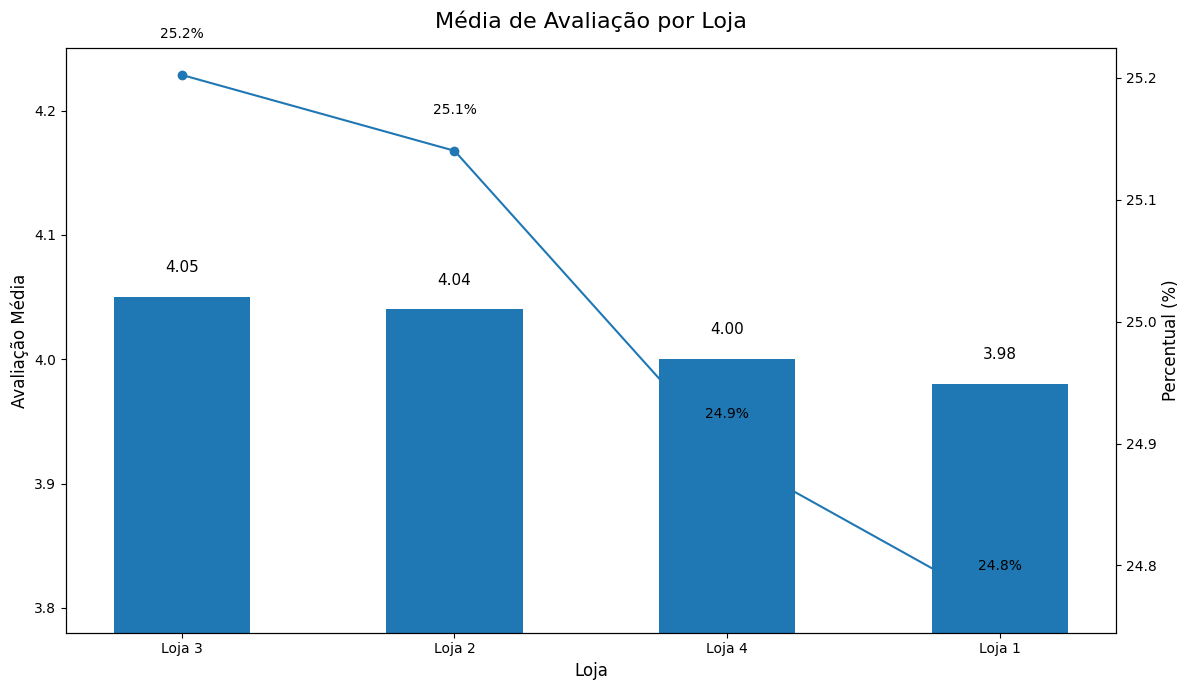

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Percentual
percentual_avaliacao = (avaliacao_media / avaliacao_media.sum()) * 100

# Criando figura maior
fig, ax1 = plt.subplots(figsize=(12,7))

x = np.arange(len(avaliacao_media.index))

# Barras mais finas
barras = ax1.bar(x, avaliacao_media.values, width=0.5)

ax1.set_title('Média de Avaliação por Loja', fontsize=16, pad=15)
ax1.set_ylabel('Avaliação Média', fontsize=12)
ax1.set_xlabel('Loja', fontsize=12)

# Ajustando escala (melhora visual para médias próximas)
ax1.set_ylim(avaliacao_media.min() - 0.2, avaliacao_media.max() + 0.2)

# Rótulos das barras
for i, valor in enumerate(avaliacao_media.values):
    ax1.text(x[i], valor + 0.02,
             f'{valor:.2f}',
             ha='center',
             fontsize=11)

# Segundo eixo
ax2 = ax1.twinx()
ax2.plot(x, percentual_avaliacao.values, marker='o')
ax2.set_ylabel('Percentual (%)', fontsize=12)

# Rótulos do percentual acima da linha
for i, perc in enumerate(percentual_avaliacao.values):
    ax2.text(x[i], perc + 0.03,
             f'{perc:.1f}%',
             ha='center',
             fontsize=10)

# Ajustando eixo X
ax1.set_xticks(x)
ax1.set_xticklabels(avaliacao_media.index)

plt.tight_layout()
plt.show()


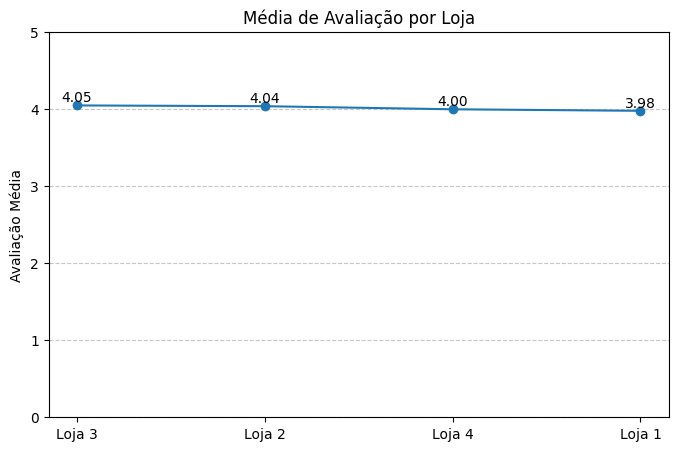

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(avaliacao_media.index, avaliacao_media.values, marker='o')

# Adicionando rótulos
for i, valor in enumerate(avaliacao_media.values):
    plt.text(i, valor + 0.05, f'{valor:.2f}', ha='center')

plt.title('Média de Avaliação por Loja')
plt.ylabel('Avaliação Média')
plt.ylim(0,5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



# 4. Produtos Mais e Menos Vendidos

In [25]:
mais_vendidos = (
    df_total.groupby(['Loja','Produto'])
    .size()
    .reset_index(name='Quantidade')
    .sort_values(['Loja','Quantidade'], ascending=False)
)

mais_vendidos.groupby('Loja').first()


,Produto,Quantidade
Loja,,
Loja 1,Guarda roupas,60
Loja 2,Iniciando em programação,65
Loja 3,Kit banquetas,57
Loja 4,Cama box,62


In [26]:
menos_vendidos = (
    df_total.groupby(['Loja','Produto'])
    .size()
    .reset_index(name='Quantidade')
    .sort_values(['Loja','Quantidade'], ascending=True)
)

menos_vendidos.groupby('Loja').first()


,Produto,Quantidade
Loja,,
Loja 1,Celular ABXY,33
Loja 2,Jogo de tabuleiro,32
Loja 3,Blocos de montar,35
Loja 4,Guitarra,33


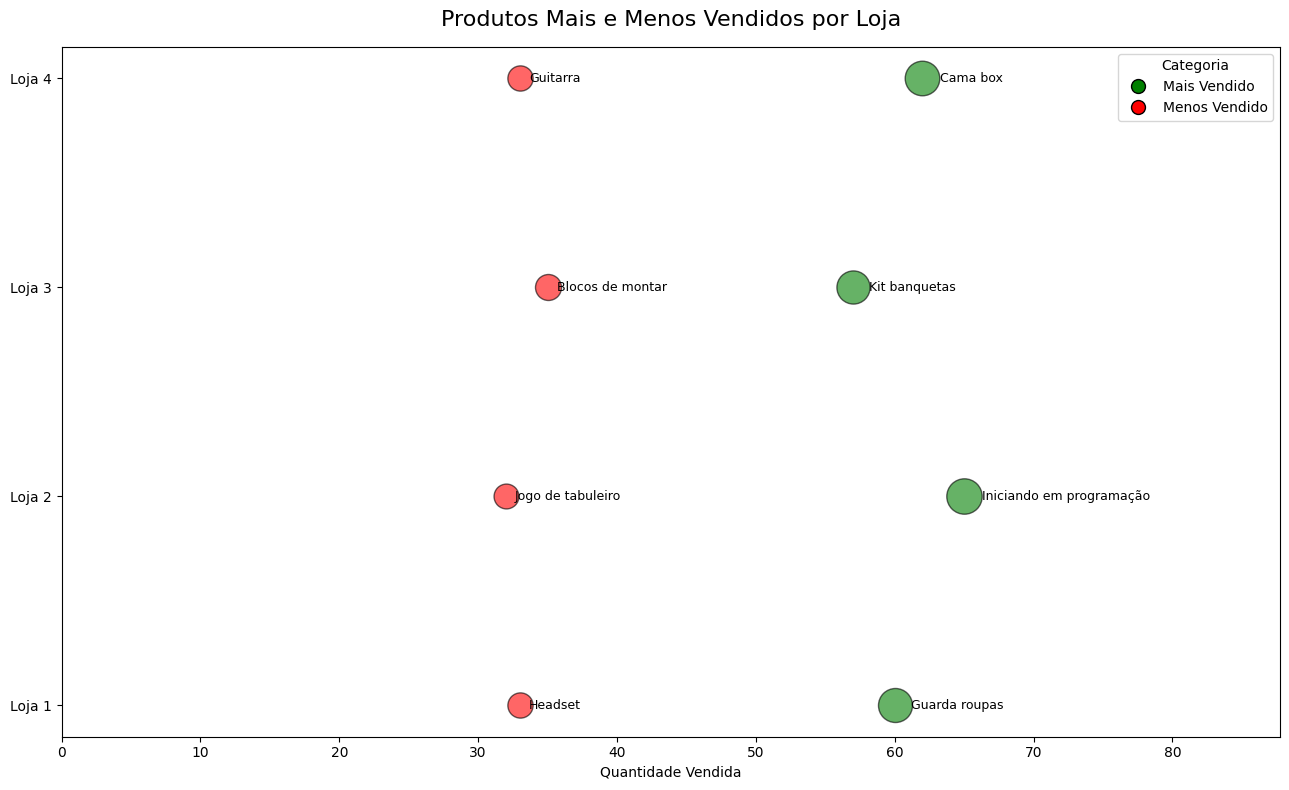

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ==============================
# 1️⃣ Encontrando mais e menos vendidos por loja
# ==============================

produtos_extremos = (
    df_total
        .groupby(['Loja', 'Produto'])
        .size()
        .reset_index(name='Quantidade')
)

produtos_extremos['Ranking'] = (
    produtos_extremos
        .groupby('Loja')['Quantidade']
        .rank(method='first', ascending=False)
)

mais = produtos_extremos[produtos_extremos['Ranking'] == 1].copy()
menos = produtos_extremos.loc[
    produtos_extremos.groupby('Loja')['Ranking'].idxmax()
].copy()

mais['Tipo'] = 'Mais Vendido'
menos['Tipo'] = 'Menos Vendido'

extremos = pd.concat([mais, menos])

# ==============================
# 2️⃣ Bubble Chart Melhorado
# ==============================

fig, ax = plt.subplots(figsize=(13,8))

lojas = extremos['Loja'].unique()
y_pos = {loja: i for i, loja in enumerate(lojas)}

cores = {
    'Mais Vendido': 'green',
    'Menos Vendido': 'red'
}

for _, row in extremos.iterrows():
    ax.scatter(
        row['Quantidade'],
        y_pos[row['Loja']],
        s=row['Quantidade'] * 10,
        alpha=0.6,
        color=cores[row['Tipo']],
        edgecolor='black'
    )

    # 🔹 Nome do produto FORA da bolha
    ax.text(
        row['Quantidade'] * 1.02,   # leve deslocamento horizontal
        y_pos[row['Loja']],
        row['Produto'],
        va='center',
        fontsize=9
    )

ax.set_yticks(range(len(lojas)))
ax.set_yticklabels(lojas)

ax.set_title('Produtos Mais e Menos Vendidos por Loja', fontsize=16, pad=15)
ax.set_xlabel('Quantidade Vendida')

ax.set_xlim(0, extremos['Quantidade'].max() * 1.35)

# Legenda
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Mais Vendido',
           markerfacecolor='green', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Menos Vendido',
           markerfacecolor='red', markeredgecolor='black', markersize=10)
]

ax.legend(handles=legend_elements, title="Categoria")

plt.tight_layout()
plt.show()


# 5. Frete Médio por Loja

In [27]:
frete_medio = df_total.groupby('Loja')['Frete'].mean().sort_values()

frete_medio


,Frete
Loja,
Loja 4,31.278997
Loja 3,33.074464
Loja 2,33.621941
Loja 1,34.691805


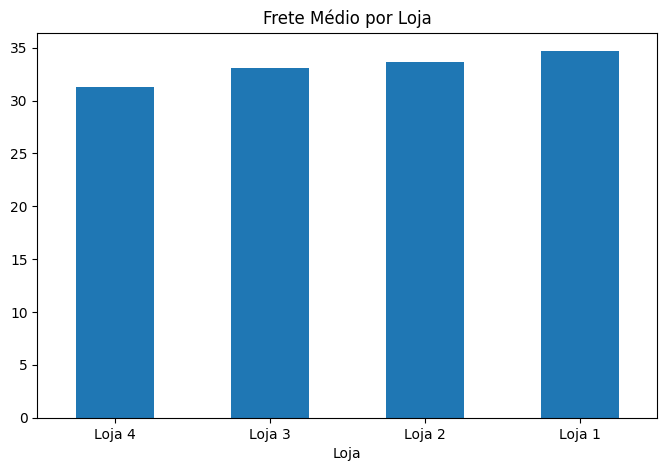

In [28]:
frete_medio.plot(kind='bar', figsize=(8,5))
plt.title('Frete Médio por Loja')
plt.xticks(rotation=0)
plt.show()


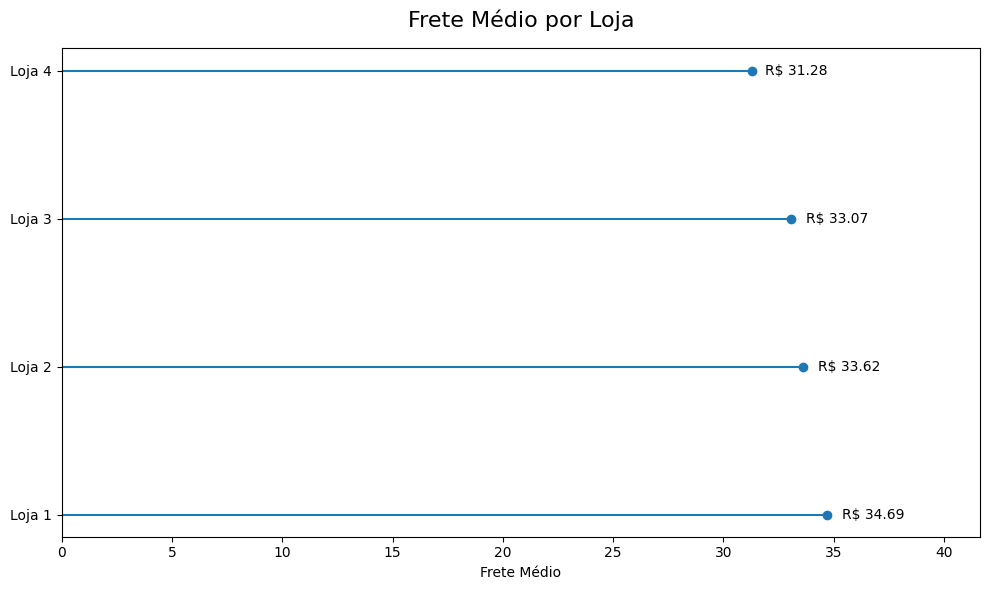

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Ordenando do maior para o menor
frete_medio = frete_medio.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,6))

y = np.arange(len(frete_medio.index))

# Criando linhas horizontais de referência
ax.hlines(y, xmin=0, xmax=frete_medio.values)

# Pontos
ax.plot(frete_medio.values, y, 'o')

# Título e rótulos
ax.set_title('Frete Médio por Loja', fontsize=16, pad=15)
ax.set_xlabel('Frete Médio')
ax.set_yticks(y)
ax.set_yticklabels(frete_medio.index)

# Ajustando limite
ax.set_xlim(0, frete_medio.max() * 1.20)

# Rótulos de valor
for i, valor in enumerate(frete_medio.values):
    ax.text(valor * 1.02, y[i],
            f'R$ {valor:.2f}',
            va='center')

plt.tight_layout()
plt.show()


# RELATÓRIO EXECUTIVO  


## Análise Estratégica de Desempenho – Rede Alura Store  

---

## 1. Contexto Estratégico

O Sr. João, proprietário da rede Alura Store, manifestou interesse em vender uma das quatro unidades com o objetivo de levantar capital para investir em um novo negócio.

Para apoiar essa decisão, foi conduzida uma análise comparativa de desempenho entre as quatro lojas, considerando indicadores financeiros, operacionais e de experiência do cliente.

O objetivo central foi identificar a unidade com menor contribuição estratégica para o portfólio da empresa.

---

# 2. Análise dos Indicadores

## 💰 2.1 Faturamento Total

| Loja   | Faturamento (R$) | Participação (%) |
|--------|------------------|------------------|
| Loja 1 | 4.563.636,11     | 26,12% |
| Loja 2 | 4.449.584,18     | 25,47% |
| Loja 3 | 4.325.091,42     | 24,76% |
| Loja 4 | 4.131.753,14     | 23,65% |

### Análise:

A Loja 4 apresentou o menor faturamento total (R$ 4.131.753,14), representando apenas 23,65% da participação no faturamento consolidado.

Comparativamente à Loja 1, a diferença supera R$ 430 mil, indicando menor geração de receita e menor contribuição financeira dentro da rede.

---

## ⭐ 2.2 Média de Avaliação dos Clientes

| Loja   | Avaliação Média |
|--------|-----------------|
| Loja 3 | 4,05 |
| Loja 2 | 4,04 |
| Loja 4 | 4,00 |
| Loja 1 | 3,98 |

### Análise:

A Loja 1 apresentou a menor média de avaliação (3,98), posicionando-se abaixo das demais unidades.

Embora a diferença seja pequena, o indicador sugere leve fragilidade na experiência do cliente quando comparada às lojas 2 e 3.

---

## 📦 2.3 Produtos Mais e Menos Vendidos

### Produtos Mais Vendidos

| Loja   | Produto                | Quantidade |
|--------|------------------------|------------|
| Loja 1 | Guarda roupas          | 60 |
| Loja 2 | Iniciando em programação | 65 |
| Loja 3 | Kit banquetas          | 57 |
| Loja 4 | Cama box               | 62 |

### Produtos Menos Vendidos

| Loja   | Produto              | Quantidade |
|--------|----------------------|------------|
| Loja 1 | Celular ABXY         | 33 |
| Loja 2 | Jogo de tabuleiro    | 32 |
| Loja 3 | Blocos de montar     | 35 |
| Loja 4 | Guitarra             | 33 |

### Análise:

Observa-se que a Loja 4 possui bom desempenho em seu produto mais vendido (62 unidades), porém isso não foi suficiente para compensar seu menor faturamento total.

A Loja 2 demonstra maior força comercial em volume unitário (65 vendas no produto líder).

---

## 🚚 2.4 Custo Médio de Frete

| Loja   | Frete Médio (R$) |
|--------|------------------|
| Loja 4 | 31,28 |
| Loja 3 | 33,07 |
| Loja 2 | 33,62 |
| Loja 1 | 34,69 |

### Análise:

A Loja 1 apresenta o maior custo médio de frete (R$ 34,69), o que pode impactar competitividade e margem de lucro.

Por outro lado, a Loja 4 possui o menor frete médio (R$ 31,28), demonstrando vantagem logística relativa.

---

# 3. Avaliação Comparativa Consolidada

Ao consolidar os indicadores estratégicos, observa-se o seguinte cenário:

- **Loja 1**: Maior faturamento, porém menor avaliação média e maior frete médio.
- **Loja 2**: Desempenho equilibrado, bom volume de vendas e avaliação alta.
- **Loja 3**: Melhor avaliação média geral e desempenho consistente.
- **Loja 4**: Menor faturamento total da rede, apesar de possuir frete competitivo.

Embora a Loja 1 apresente desafios em satisfação e frete, sua liderança em faturamento mantém sua relevância estratégica.

A Loja 4, por sua vez, apresenta a menor geração de receita entre as quatro unidades, fator crítico em uma decisão de desinvestimento.

---

# 4. Recomendação Estratégica

Com base na análise quantitativa e comparativa realizada, recomenda-se que o Sr. João considere a venda da **Loja 4**.

A decisão é fundamentada nos seguintes pontos:

- Menor faturamento total da rede (R$ 4,13 milhões)
- Menor participação percentual (23,65%)
- Desempenho comercial inferior quando comparado às demais unidades

Apesar de apresentar vantagem no custo de frete, o indicador financeiro tem maior peso estratégico na decisão de alocação de capital.

---

# 5. Considerações Finais

A análise demonstra como decisões empresariais podem ser conduzidas de forma estruturada e orientada por dados.

A venda da Loja 4 permitirá ao Sr. João:

- Liberar capital com menor impacto financeiro relativo
- Manter as unidades mais rentáveis e competitivas
- Reinvestir estrategicamente em novas oportunidades de negócio

Este estudo reforça a importância da cultura data-driven na gestão empresarial e evidencia como métricas bem estruturadas sustentam decisões estratégicas com maior segurança e assertividade.



# RELATÓRIO EXECUTIVO – BOARD


## Avaliação Estratégica das Unidades | Alura Store  

---

## 🎯 Objetivo

Avaliar o desempenho das quatro unidades da Alura Store para recomendar, com base em dados, qual loja deve ser vendida para geração de capital e reinvestimento estratégico.

---

# 📊 Panorama Geral de Desempenho

## 💰 Faturamento Total

| Loja   | Faturamento (R$) | Participação |
|--------|------------------|--------------|
| Loja 1 | 4,56 mi | 26,12% |
| Loja 2 | 4,45 mi | 25,47% |
| Loja 3 | 4,33 mi | 24,76% |
| Loja 4 | 4,13 mi | 23,65% |

🔎 **Insight-chave:**  
A Loja 4 apresenta o menor faturamento absoluto e a menor participação percentual na receita consolidada.

---

## ⭐ Satisfação do Cliente (Média de Avaliação)

| Loja   | Nota Média |
|--------|------------|
| Loja 3 | 4,05 |
| Loja 2 | 4,04 |
| Loja 4 | 4,00 |
| Loja 1 | 3,98 |

🔎 **Insight-chave:**  
Diferença pouco significativa entre as unidades. A Loja 4 mantém avaliação competitiva (4,00), não sendo o principal fator crítico.

---

## 🚚 Custo Médio de Frete

| Loja   | Frete Médio (R$) |
|--------|------------------|
| Loja 4 | 31,28 |
| Loja 3 | 33,07 |
| Loja 2 | 33,62 |
| Loja 1 | 34,69 |

🔎 **Insight-chave:**  
A Loja 4 possui a melhor eficiência logística entre as unidades.

---

## 📦 Dinâmica Comercial

- Loja 2 apresenta maior volume unitário em produto líder (65 vendas).
- Loja 4 possui desempenho comercial moderado, mas inferior em geração de receita total.
- Não há desequilíbrios críticos de mix de produtos que compensem a diferença de faturamento da Loja 4.

---

# 🧠 Análise Estratégica Consolidada

Embora a Loja 4 apresente vantagem logística (menor frete médio) e avaliação satisfatória, seu desempenho financeiro é consistentemente inferior.

O faturamento é o principal indicador estratégico para decisões de portfólio, pois impacta:

- Geração de caixa
- Capacidade de reinvestimento
- Escalabilidade operacional
- Retorno sobre capital

A Loja 4 representa a menor contribuição relativa à receita total da rede.

---

# ✅ Recomendação ao Board

Recomenda-se a venda da **Loja 4**, considerando:

- Menor faturamento absoluto (R$ 4,13 milhões)
- Menor participação na receita consolidada (23,65%)
- Impacto financeiro proporcionalmente menor no portfólio geral

A alienação dessa unidade permitirá:

✔ Liberação de capital com menor perda de receita relativa  
✔ Foco estratégico nas unidades mais rentáveis  
✔ Reinvestimento estruturado em nova oportunidade de negócio  

---

## 📌 Conclusão Executiva

A decisão proposta é fundamentada em análise comparativa objetiva e orientada por dados.

A venda da Loja 4 representa a alternativa com menor impacto financeiro negativo e maior coerência estratégica para otimização do portfólio da Alura Store.

